# Modul 3 — Visualisasi Data (Matplotlib & Seaborn)
## Convergeni Data Consulting (CDC) — Klien: PT Ritel Sentosa

Notebook ini menjalankan seluruh kode visualisasi Modul 3: data performa bulanan
sintetis 180 gerai, grafik garis sumbu jujur vs dipotong, grafik batang wilayah,
pie chart 8 kategori, dan perbandingan gaya Matplotlib polos vs Seaborn.

## Data Sintetis Performa Bulanan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

wilayah_gerai = {"Jabodetabek": 60, "Jawa Barat": 35, "Jawa Tengah & DIY": 30, "Jawa Timur": 35, "Luar Jawa": 20}
rata_rata_per_gerai = {"Jabodetabek": 1650, "Jawa Barat": 1300, "Jawa Tengah & DIY": 1150, "Jawa Timur": 1250, "Luar Jawa": 1000}
bulan = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]
tren_musiman = np.array([0.97,0.96,0.99,1.00,1.02,1.08,1.01,0.98,0.99,1.00,1.02,1.12])

rows = []
for wilayah, n_gerai in wilayah_gerai.items():
    base = rata_rata_per_gerai[wilayah]
    for i, nama_bulan in enumerate(bulan):
        pendapatan_gerai = np.random.normal(loc=base * tren_musiman[i], scale=base * 0.12, size=n_gerai)
        rows.append({"wilayah": wilayah, "bulan": nama_bulan, "bulan_idx": i,
                      "jumlah_gerai": n_gerai, "total_pendapatan_juta": pendapatan_gerai.sum()})

df = pd.DataFrame(rows)
print(df.shape)
total_bulanan = df.groupby("bulan_idx")["total_pendapatan_juta"].sum() / 1000
total_bulanan.index = bulan
print(total_bulanan.round(1))

(60, 5)
Jan    233.0
Feb    233.3
Mar    241.7
Apr    245.0
Mei    249.6
Jun    266.0
Jul    246.7
Agu    237.0
Sep    238.2
Okt    242.7
Nov    251.4
Des    273.8
Name: total_pendapatan_juta, dtype: float64


## Visualisasi 1: Sumbu Jujur vs Sumbu Dipotong (Asset Baru, mengganti M03-01)

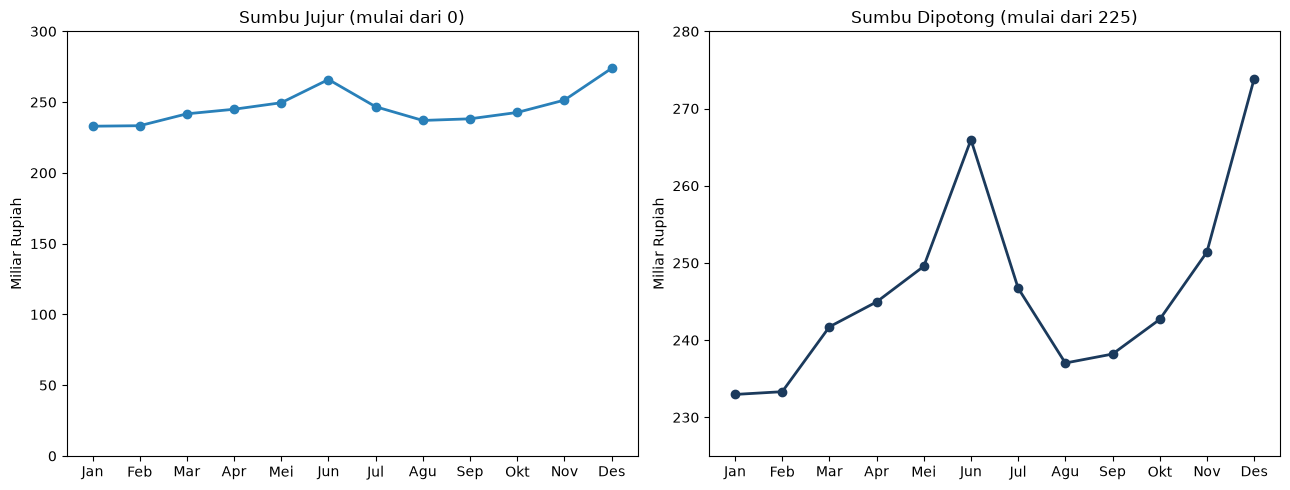

Titik terendah: 233.0 Titik tertinggi: 273.8
Rentang variasi: 40.8 miliar


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(bulan, total_bulanan.values, marker="o", linewidth=2, color="#2980B9")
axes[0].set_ylim(0, 300)
axes[0].set_title("Sumbu Jujur (mulai dari 0)")
axes[0].set_ylabel("Miliar Rupiah")

axes[1].plot(bulan, total_bulanan.values, marker="o", linewidth=2, color="#1B3A5C")
axes[1].set_ylim(225, 280)
axes[1].set_title("Sumbu Dipotong (mulai dari 225)")
axes[1].set_ylabel("Miliar Rupiah")

plt.tight_layout()
plt.savefig("modul03_sumbu_jujur_vs_dipotong.png", dpi=150, bbox_inches="tight")
plt.show()
print("Titik terendah:", round(total_bulanan.min(), 1), "Titik tertinggi:", round(total_bulanan.max(), 1))
print("Rentang variasi:", round(total_bulanan.max() - total_bulanan.min(), 1), "miliar")

## Visualisasi 2: Grafik Batang Wilayah dan Pie Chart 8 Kategori (Asset Baru, mengganti M03-02)

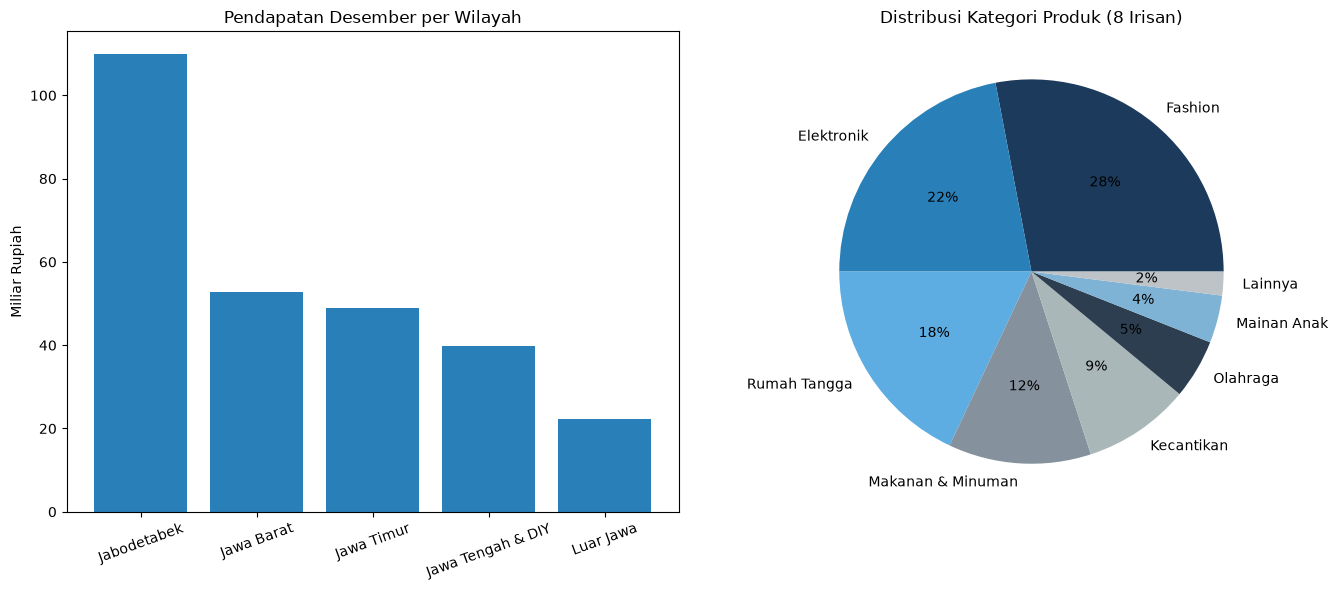

          wilayah  total_pendapatan_miliar
      Jabodetabek                    109.9
       Jawa Barat                     52.9
       Jawa Timur                     49.0
Jawa Tengah & DIY                     39.8
        Luar Jawa                     22.2


In [3]:
des = df[df["bulan"] == "Des"].sort_values("total_pendapatan_juta", ascending=False).copy()
des["total_pendapatan_miliar"] = des["total_pendapatan_juta"] / 1000

kategori_produk = {"Fashion": 28, "Elektronik": 22, "Rumah Tangga": 18, "Makanan & Minuman": 12,
                    "Kecantikan": 9, "Olahraga": 5, "Mainan Anak": 4, "Lainnya": 2}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(des["wilayah"], des["total_pendapatan_miliar"], color="#2980B9")
axes[0].set_title("Pendapatan Desember per Wilayah")
axes[0].set_ylabel("Miliar Rupiah")
axes[0].tick_params(axis="x", rotation=20)

warna_pie = ["#1B3A5C", "#2980B9", "#5DADE2", "#85929E", "#AAB7B8", "#2C3E50", "#7FB3D5", "#BDC3C7"]
axes[1].pie(kategori_produk.values(), labels=kategori_produk.keys(), autopct="%1.0f%%", colors=warna_pie)
axes[1].set_title("Distribusi Kategori Produk (8 Irisan)")

plt.tight_layout()
plt.savefig("modul03_bar_vs_pie.png", dpi=150, bbox_inches="tight")
plt.show()
print(des[["wilayah", "total_pendapatan_miliar"]].round(1).to_string(index=False))

## Visualisasi 3: Matplotlib Polos vs Seaborn Whitegrid (Asset Baru, mengganti M03-03)

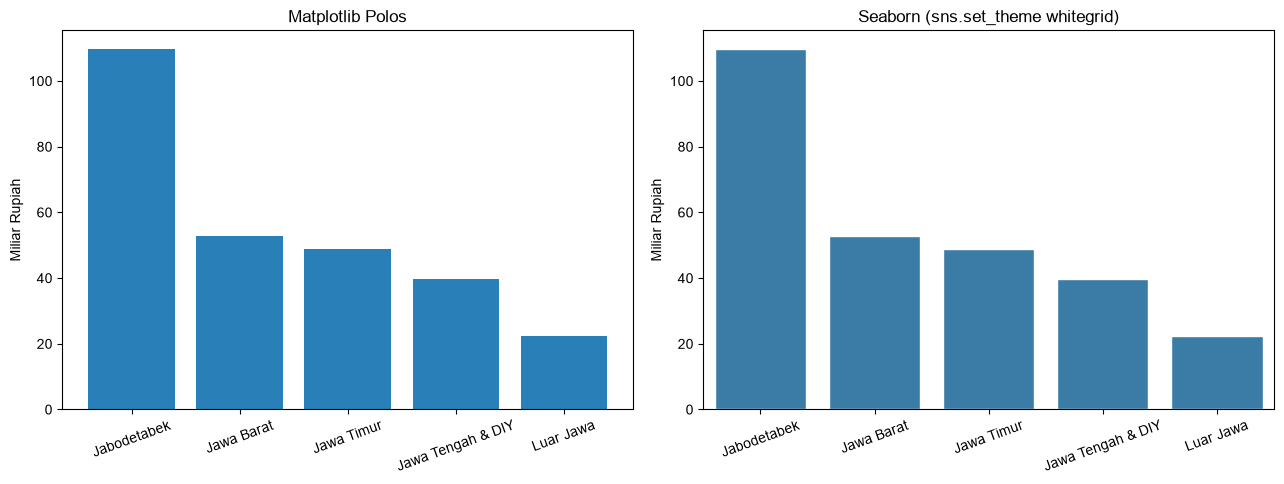

In [4]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(des["wilayah"], des["total_pendapatan_miliar"], color="#2980B9")
axes[0].set_title("Matplotlib Polos")
axes[0].set_ylabel("Miliar Rupiah")
axes[0].tick_params(axis="x", rotation=20)

sns.set_theme(style="whitegrid")
sns.barplot(data=des, x="wilayah", y="total_pendapatan_miliar", ax=axes[1], color="#2980B9")
axes[1].set_title("Seaborn (sns.set_theme whitegrid)")
axes[1].set_ylabel("Miliar Rupiah")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("modul03_matplotlib_vs_seaborn.png", dpi=150, bbox_inches="tight")
plt.show()